# BER Replication
> **Paper:** Burnside, Eichenbaum & Rebelo (2011), "Carry Trade and Momentum in Currency Markets"

A **light** replication -- just enough to sanity-check the pipeline once real Bloomberg data lands in `data/raw/`, not a full reproduction of every table:

- The core **Currency Return** calculation (`FXPanel.rx`, i.e. `f_t - s_{t+1}`) that everything else is built on.
- Equally-weighted **carry** and **momentum** portfolios (BER-style +-1/N, not sorted into buckets).
- A 50/50 blend of the two.
- Table-1-style summary stats (mean, vol, Sharpe, skew, kurtosis) and the carry/momentum correlation.
- A Figure-1-style cumulative NAV plot, compounding strategy excess returns on top of the US 1M T-bill rate.

**Not covered yet:** Table 5 (S1-S5 sorted portfolios), the VOL factor, and the DOL/HML/VOL time-series regressions -- left for a follow-up pass.

Everything below runs through the `fxcarry` library (`fxcarry.signals`, `fxcarry.portfolio`, `fxcarry.metrics`) -- no ad-hoc formulas -- so swapping in more currencies or a different sample window only means editing `fxcarry/constants.py` or the `DATA_DIR`/`TICKERS` cell below.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../src")

from fxcarry import constants as const
from fxcarry import io as fxio
from fxcarry.metrics import summary_table
from fxcarry.panel import FXPanel
from fxcarry.portfolio import ew_strategy_return
from fxcarry.signals import carry_signal, momentum_signal

DATA_DIR = Path("data/raw")  # own data folder, not the shared top-level data/
TICKERS = const.DEFAULT_TICKERS  # BER-20 by default; edit fxcarry/constants.py to change.

panel = FXPanel.from_raw(DATA_DIR, freq=const.DEFAULT_FREQ, tickers=TICKERS)
print(f"Panel: {panel.rx.shape[0]} periods x {len(panel.currencies)} currencies")
print(f"Sample: {panel.rx.dropna(how='all').index.min()} -> {panel.rx.dropna(how='all').index.max()}")

Panel: 512 periods x 18 currencies
Sample: 1984-01-31 00:00:00 -> 2026-06-30 00:00:00


## Currency Return

The building block for every strategy below: `rx_{t+1} = f_t - s_{t+1}`, the log excess return on being long a currency forward from `t` to `t+1`. `FXPanel.currency_return("excess")` is an explicit, discoverable alias for `panel.rx`; `currency_return("spot")` is the pure spot-only variant (no interest/carry component) for comparison.

Currency (excess) return -- per-currency, per-period:


ticker,AUD,CAD,CHF,CZK,DKK,EUR,GBP,HKD,HUF,JPY,KRW,MXN,NOK,NZD,PLN,SEK,SGD,ZAR
2026-02-28,0.021920,-0.003171,0.001792,-0.000535,-0.005202,-0.004618,-0.014987,-0.002205,0.010510,-0.010564,0.000579,0.016018,0.013160,-0.004873,-0.005125,-0.013463,0.002137,0.015201
2026-03-31,-0.030979,-0.021341,-0.042306,-0.034475,-0.024122,-0.023849,-0.019190,-0.003616,-0.039090,-0.019641,-0.053577,-0.037473,-0.018541,-0.044039,-0.038063,-0.049436,-0.019424,-0.058667
2026-04-30,0.043080,0.022974,0.019365,0.021875,0.013298,0.013768,0.028144,-0.000856,0.069525,0.010529,0.028428,0.029144,0.045942,0.026588,0.023482,0.022734,0.008338,0.018418
2026-05-31,-0.001677,-0.016716,-0.002840,-0.002039,-0.007814,-0.007611,-0.010908,-0.001774,0.025297,-0.019671,-0.018193,0.008964,0.001467,0.012393,-0.000358,-0.002218,-0.004855,0.029417
2026-06-30,-0.037135,-0.030112,-0.037703,-0.019926,-0.022466,-0.021849,-0.014469,-0.001838,-0.023885,-0.022866,-0.029684,-0.005054,-0.067904,-0.054168,-0.036197,-0.049646,-0.015535,-0.007546



Cross-currency average excess return per period (equal-weight DOL-style):


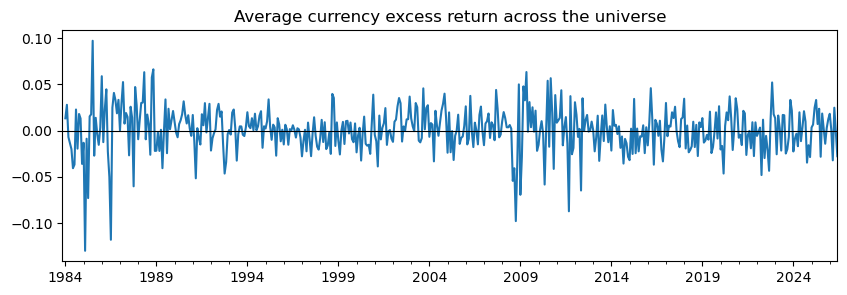

In [2]:
currency_excess_return = panel.currency_return("excess")  # == panel.rx
currency_spot_return = panel.currency_return("spot")

print("Currency (excess) return -- per-currency, per-period:")
display(currency_excess_return.tail())

print("\nCross-currency average excess return per period (equal-weight DOL-style):")
currency_excess_return.mean(axis=1).plot(figsize=(10, 3), title="Average currency excess return across the universe")
plt.axhline(0.0, color="black", linewidth=0.8)
plt.show()

## Equally-weighted carry, momentum, and 50-50 strategies

`ew_strategy_return` gives every currency a `+-1/N` weight based on the sign of the signal, lagged one period so nothing looks ahead (see `fxcarry.portfolio` / `fxcarry.signals` docstrings for the exact convention).

In [3]:
carry_sig = carry_signal(panel)  # forward discount, f_t - s_t
mom_sig = momentum_signal(panel, lookback=1)  # BER: previous month's currency return

carry_ew = ew_strategy_return(carry_sig, panel.rx).rename("Carry")
mom_ew = ew_strategy_return(mom_sig, panel.rx).rename("Momentum")
fifty_fifty = (0.5 * carry_ew + 0.5 * mom_ew).rename("50-50")

strategies = pd.concat([carry_ew, mom_ew, fifty_fifty], axis=1).dropna(how="all")
strategies.tail()

,Carry,Momentum,50-50
2026-02-28,0.005379,0.001101,0.003240
2026-03-31,0.007345,-0.001238,0.003053
2026-04-30,0.003928,-0.024710,-0.010391
2026-05-31,0.006863,-0.000866,0.002999
2026-06-30,0.006311,0.010048,0.008180


## Table 1

Rough sanity bands, not a strict target: carry Sharpe around [0.5, 1.0], momentum Sharpe around [0.3, 0.8], carry-momentum correlation low (paper reports ~0.10; anything comfortably below 0.3 looks right).

In [4]:
stats = summary_table(strategies, annualize=const.DEFAULT_ANNUALIZATION)
display(stats)

corr = carry_ew.corr(mom_ew)
print(f"Carry vs. Momentum correlation: {corr:.3f}")

,mean_ann,std_ann,sharpe,skew,kurtosis,nw_se_mean_ann,n_obs
Carry,0.027852,0.062939,0.442530,-1.188947,11.579056,0.010156,512.0
Momentum,0.030619,0.069752,0.438973,1.450669,7.666621,0.011658,512.0
50-50,0.029236,0.044899,0.651144,1.333373,10.337156,0.007191,512.0


Carry vs. Momentum correlation: -0.087


## Figure 1

`panel.rx` is an *excess* return (over the risk-free rate), so the BER-style total-return NAV compounds `strategy_excess_return + tbill_rate` each period, matching the paper's Figure 1 convention of showing what a fully-invested (T-bill + carry) strategy would have earned.

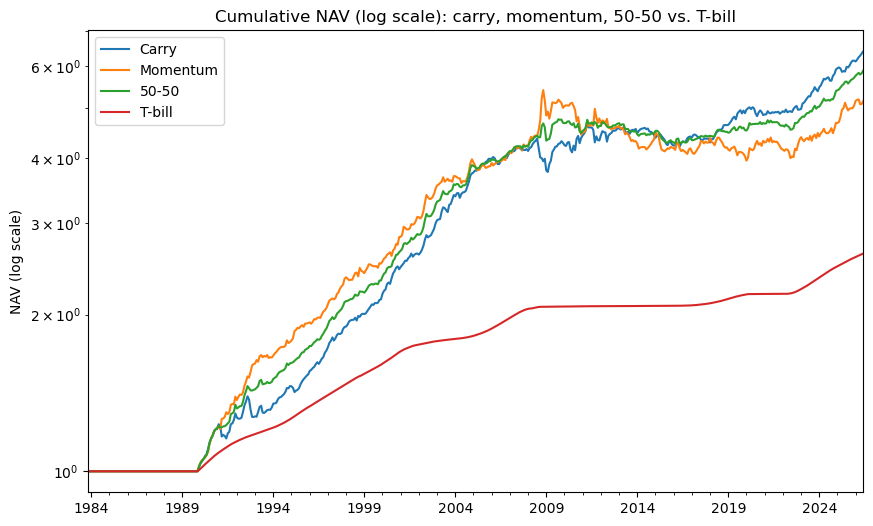

In [5]:
tbill_rate = fxio.load_yield_series(DATA_DIR / const.TBILL_FILE, freq=const.DEFAULT_FREQ)
tbill_rate = tbill_rate.reindex(strategies.index)

total_return = strategies.add(tbill_rate, axis=0)
nav = (1.0 + total_return.fillna(0.0)).cumprod()
tbill_nav = (1.0 + tbill_rate.fillna(0.0)).cumprod().rename("T-bill")

nav_plot = pd.concat([nav, tbill_nav], axis=1)
ax = nav_plot.plot(figsize=(10, 6), logy=True, title="Cumulative NAV (log scale): carry, momentum, 50-50 vs. T-bill")
ax.set_ylabel("NAV (log scale)")
plt.show()